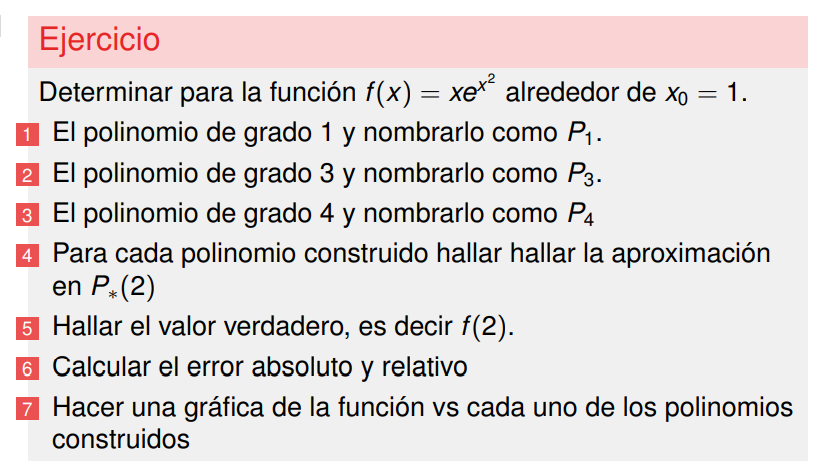

P1 = 8.15484548537714*x - 5.43656365691809
P3 = 17.215784913574*x**3 - 38.0559455984266*x**2 + 32.6193819415085*x - 9.06093942819682
P4 = 17.6688318849838*x**4 - 53.4595426263612*x**3 + 67.9570457114761*x**2 - 38.0559455984266*x + 8.60789245678697

Aproximaciones de los polinomios en 2: 
P1 evaluado en 2 es = 10.87312731383619
P3 evaluado en 2 es = 41.68032136970581
P4 evaluado en 2 es = 59.34915325468937

Valores verdaderos: 
El Valor verdadero= 109.19630006628847

Valores Absolutos:
P1 = 98.32317275245228
P3 = 67.51597869658266
P4 = 49.8471468115991

Valores Relativos: 
P1 = 0.900425863264272
P3 = 0.618299142513039
P4 = 0.45649117031748326

Gráfica de la función y los polinomios:



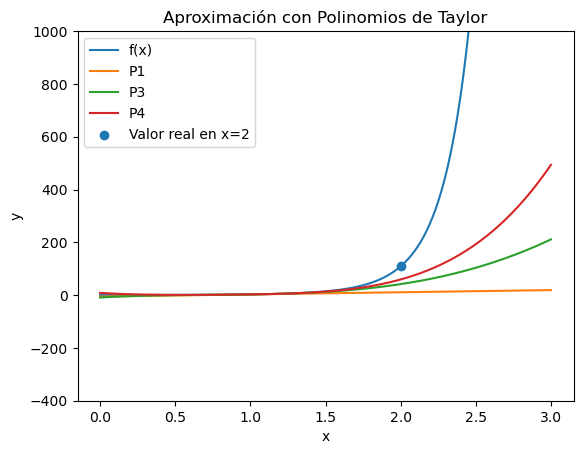

In [43]:
import sympy as sp
from math import factorial
import numpy as np
import matplotlib.pyplot as plt
x = sp.symbols("x")
f = x*sp.exp(x**2)
x0 = 1

def Taylor_serie(f, x0, n):
    polinomio = 0               
    for k in range(n + 1):     
        df = sp.diff(f, x, k) 
        df_eval = sp.lambdify(x, df)                        
        valor_derivada = df_eval(x0)  

        termino = (valor_derivada / factorial(k)) * (x - x0)**k  

        polinomio += termino  

    return sp.expand(polinomio)

P1=Taylor_serie(f, 1, 1)
print(f"P1 = {P1}")
P3=Taylor_serie(f, 1, 3)
print(f"P3 = {P3}")
P4=Taylor_serie(f, 1, 4)
print(f"P4 = {P4}")

print("\nAproximaciones de los polinomios en 2: ")

P1_eval= sp.lambdify(x,P1)
P1_valor=P1_eval(2)
print(f"P1 evaluado en 2 es = {P1_valor}")
P3_eval= sp.lambdify(x,P3)
P3_valor=P3_eval(2)
print(f"P3 evaluado en 2 es = {P3_valor}")
P4_eval= sp.lambdify(x,P4)
P4_valor=P4_eval(2)
print(f"P4 evaluado en 2 es = {P4_valor}")

print("\nValores verdaderos: ")

Eval_funcion= sp.lambdify(x,f)
Valor_real = Eval_funcion(2)
print(f"El Valor verdadero= {Valor_real}")

print(f"\nValores Absolutos:")

def errores_abs(Ve, Va):
    Ea = abs(Ve-Va)
    return (Ea)

Ea_P1=errores_abs(Valor_real, P1_valor)
print(F"P1 = {Ea_P1}")
Ea_P3=errores_abs(Valor_real, P3_valor)
print(F"P3 = {Ea_P3}")
Ea_P4=errores_abs(Valor_real, P4_valor)
print(F"P4 = {Ea_P4}")    

print("\nValores Relativos: ")

def errores_rel(ea,ve):
    Er = abs (ea) /abs(ve)
    return Er

Er_P1 =errores_rel(Ea_P1,Valor_real)
print(f"P1 = {Er_P1}")
Er_P3 =errores_rel(Ea_P3,Valor_real)
print(f"P3 = {Er_P3}")
Er_P4 =errores_rel(Ea_P4,Valor_real)
print(f"P4 = {Er_P4}")
    

print("\nGráfica de la función y los polinomios:\n")

# Rango de valores para graficar
x_vals = np.linspace(0, 3, 400)

# Usamos tus mismas funciones ya definidas con lambdify
f_vals = Eval_funcion(x_vals)
P1_vals = P1_eval(x_vals)
P3_vals = P3_eval(x_vals)
P4_vals = P4_eval(x_vals)

plt.figure()

plt.plot(x_vals, f_vals)
plt.plot(x_vals, P1_vals)
plt.plot(x_vals, P3_vals)
plt.plot(x_vals, P4_vals)

# Punto real en x=2
plt.scatter(2, Valor_real)

plt.legend(["f(x)", "P1", "P3", "P4", "Valor real en x=2"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Aproximación con Polinomios de Taylor")
plt.ylim(-400,1000)
plt.show()



